# Redes Adaline

**Adaline** é um modelo de neurônio artificial que utiliza uma **função de ativação linear** durante o treinamento e aprende pelo método do **Gradiente Descendente**, minimizando o **Erro Quadrático Médio (MSE)** entre a saída linear e o rótulo alvo.

O estudo teórico sobre redes Peceptron está disponível em slides. Clique [aqui](https://github.com/pedrothiag/intelligent-systems/blob/main/slides/07_adaline.pdf) para acessar os slides.

### Implementação Manual

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, confusion_matrix)

In [2]:
# ── Configurações de Plotagem ────────────────────────────────────────────────
plt.rcParams["font.family"] = "Arial"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams['mathtext.rm'] = "Arial"
plt.rcParams['mathtext.it'] = "Arial:italic"
plt.rcParams['mathtext.bf'] = "Arial:bold"
plt.rcParams['figure.figsize'] = (8, 5)

In [4]:
# Dataset: Breast Cancer (classificacao binaria)
data = load_breast_cancer()
X, y = data.data, data.target

# Adaline usa rotulos {-1, +1}
# y_adaline = 2*y - 1
y_adaline = np.where(y == 0, -1, 1)

# Criar o dataframe para facilitar a visualizacao
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y_adaline
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,-1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,-1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,-1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,-1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,-1


In [29]:
data.target_names

array(['malignant', 'benign'], dtype='<U9')

In [5]:
# Divisao treino / teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y_adaline, test_size=0.2, random_state=42, stratify=y_adaline
)

# Normalizacao
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Amostras de treino : {X_train.shape[0]}")
print(f"Amostras de teste  : {X_test.shape[0]}")
print(f"Features           : {X_train.shape[1]}")

Amostras de treino : 455
Amostras de teste  : 114
Features           : 30


A regra de atualização do Adaline:

$$w \leftarrow w + \eta \left(y_d^{(k)} - u\right)  x^{(k)}$$

In [23]:
class AdalineManual:
    def __init__(self, learning_rate=0.001, n_epochs=50):
        self.lr           = learning_rate
        self.n_epochs     = n_epochs
        self.weights      = None
        self.cost_        = []

    def fit(self, X_raw, yd):
        X = np.column_stack((-1.0*np.ones(X_raw.shape[0]), X_raw))      # Adiciona o termo de bias (coluna de -1)
        w = 0.1*np.random.randn(X.shape[1])                             # Inicializa os pesos com valores aleatórios pequenos
        n_samples = X.shape[0]                                          # Número de amostras

        indexes = np.arange(n_samples)                                  # Índices para embaralhar as amostras

        for _ in range(self.n_epochs):
            np.random.shuffle(indexes)                                  # Embaralha os índices para garantir
            epoch_cost = 0.0
            for idx in indexes:
                u           = np.dot(X[idx,:], w)                          # saida linear
                error       = yd[idx] - u                                  # erro escalar
                w          += self.lr * X[idx,:] * error                   # atualiza pesos
                epoch_cost += error ** 2
            self.cost_.append(epoch_cost / (n_samples))
        
        self.weights = w
        return self

    def predict(self, X_raw):
        X = np.column_stack((-1.0*np.ones(X_raw.shape[0]), X_raw))
        u = np.dot(X, self.weights)
        return np.where(u >= 0.0, 1, -1)


# Treinamento
adaline_manual = AdalineManual(learning_rate=0.001, n_epochs=100)
adaline_manual.fit(X_train, y_train)

(0.0, 99.0)

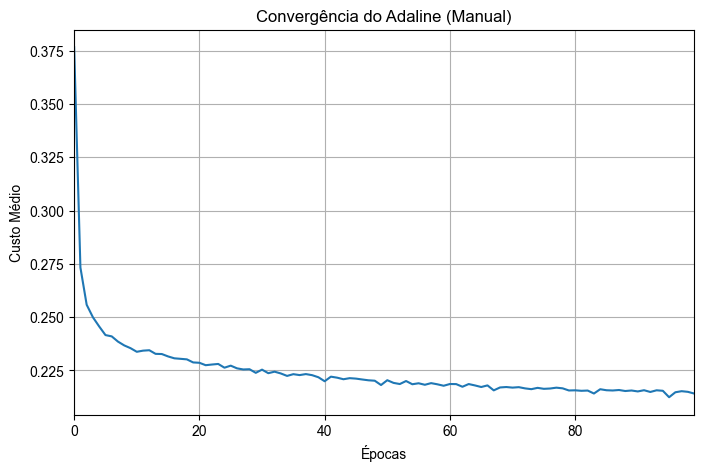

In [24]:
epochs = np.arange(0, len(adaline_manual.cost_))
plt.plot(epochs, adaline_manual.cost_)
plt.xlabel('Épocas')
plt.ylabel('Custo Médio')
plt.title('Convergência do Adaline (Manual)')
plt.grid()
plt.xlim([min(epochs), max(epochs)])

In [25]:
y_pred_manual = adaline_manual.predict(X_test)

confusionMatriz = confusion_matrix(y_test, y_pred_manual)
print("Matriz de Confusão:")
print(confusionMatriz)

Matriz de Confusão:
[[38  4]
 [ 0 72]]


In [30]:
print('Acurácia :', accuracy_score(y_test, y_pred_manual))
print('Precisão  :', precision_score(y_test, y_pred_manual))
print('Recall    :', recall_score(y_test, y_pred_manual))
print('F1-Score  :', f1_score(y_test, y_pred_manual))

Acurácia : 0.9649122807017544
Precisão  : 0.9473684210526315
Recall    : 1.0
F1-Score  : 0.972972972972973


### Implementação com `scikit-learn`

O `SGDClassifier` com `loss='squared_error'` minimiza o MSE usando SGD, sendo a implementação do Adaline na biblioteca `scikit-learn`.

In [31]:
adaline_sklearn = SGDClassifier(
    loss='squared_error',
    eta0=0.001,
    learning_rate='constant',
    max_iter=100,
    shuffle=True
)
adaline_sklearn.fit(X_train, y_train)
y_pred_sklearn = adaline_sklearn.predict(X_test)

In [32]:
confusionMatriz = confusion_matrix(y_test, y_pred_sklearn)
print("Matriz de Confusão (Com sklearn):")
print(confusionMatriz)

Matriz de Confusão (Com sklearn):
[[39  3]
 [ 1 71]]


In [33]:
print('Acurácia :', accuracy_score(y_test, y_pred_sklearn))
print('Precisão  :', precision_score(y_test, y_pred_sklearn))
print('Recall    :', recall_score(y_test, y_pred_sklearn))
print('F1-Score  :', f1_score(y_test, y_pred_sklearn))

Acurácia : 0.9649122807017544
Precisão  : 0.9594594594594594
Recall    : 0.9861111111111112
F1-Score  : 0.9726027397260274
